# Ayudantía 10: Laboratorio 5 Parte 1 #
Juan Pablo Tapia | jp.tapia@uc.cl

29 de Mayo, 2025.

## Descargando Datos

In [77]:
!unzip Data_L5.zip

Archive:  Data_L5.zip
replace __MACOSX/Data L5/._Comunas? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

## Importando Librerías

In [1]:
!pip install osmnx

In [90]:
import osmnx as ox
import networkx as nx
import geopandas as gpd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import Point, LineString
from IPython.display import display #para mostrar más de un elemento por celda de Jupyter

## a) Ruta multimodal desde el Cerro Chena a la sala de clases

Coordenadas Cerro Chena y Sala A1

In [49]:
cerro_chena = (-33.593891, -70.742777)
sala_A1 = (-33.50021288215604, -70.61254947907959) # Recuperada de GoogleMaps

Se obtienen los datos de Santiago urbano

In [78]:
chile_urbano = gpd.read_file('Data L5/Areas Urbanas/areas_urbanas.shp')
chile_urbano.to_crs("EPSG:4326", inplace=True)
santiago_urbano = chile_urbano.loc[chile_urbano['NOMBRE']=='Santiago']
comunas = gpd.read_file('Data L5/Comunas/comunas.shp')
comunas = comunas[comunas['Region'] == 'Región Metropolitana de Santiago']
comunas = comunas.to_crs(epsg=4326)

Filtramos solo las comunas que nos interesan

In [79]:
comunas = comunas.to_crs(epsg=4326)

comunas_macul_sb = comunas[comunas['Comuna'].isin(['Macul', 'San Bernardo', 'San Joaquín', 'El Bosque', 'La Pintana', 'La Cisterna', 'San Ramón', 'La Granja', 'La Florida', 'San Miguel'])]
zona = comunas_macul_sb.unary_union

G_walk = ox.graph_from_polygon(zona, network_type='walk')

<ipython-input-79-f2b485c6539c>:4: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  zona = comunas_macul_sb.unary_union


In [81]:
orig_node_total = ox.distance.nearest_nodes(G_walk, X=sala_A1[1], Y=sala_A1[0])
dest_node_total = ox.distance.nearest_nodes(G_walk, X=cerro_chena[1], Y=cerro_chena[0])
ruta_optima = nx.shortest_path(G_walk, orig_node_total, dest_node_total, weight='length')

Importamos estaciones y lineas de metro

In [65]:
estaciones_metro = gpd.read_file('Data L5/Metro 2020/Estaciones_2020/Estaciones_2020.shp')
lineas_metro = gpd.read_file('Data L5/Metro 2020/Lineas_2020/Lineas_2020.shp')

Procesamos los datos

In [66]:
estaciones_metro.to_crs("EPSG:32719", inplace=True)
lineas_metro.to_crs("EPSG:32719", inplace=True)

# Asignar ID único a estaciones y agregar coordenadas x/y
estaciones_metro = estaciones_metro.reset_index(drop=True)
estaciones_metro['node_id'] = estaciones_metro.index
estaciones_metro['x'] = estaciones_metro.geometry.x
estaciones_metro['y'] = estaciones_metro.geometry.y
estaciones_metro = estaciones_metro.set_index('node_id')

# Definir nodos u y v para cada linestring (estaciones más cercanas a inicio y fin)
def nearest_node(point):
    return estaciones_metro.geometry.distance(point).idxmin()
lineas_metro = lineas_metro.reset_index(drop=True)
lineas_metro['u'] = lineas_metro.geometry.apply(lambda x: nearest_node(Point(x.coords[0])))
lineas_metro['v'] = lineas_metro.geometry.apply(lambda x: nearest_node(Point(x.coords[-1])))

# Establecer índice múltiple (u,v,key) y agregar la longitud como peso
lineas_metro['key'] = 0
lineas_metro.set_index(['u', 'v', 'key'], inplace=True)
lineas_metro['length'] = lineas_metro.geometry.length

estaciones_metro.to_crs("EPSG:4326", inplace=True)
lineas_metro.to_crs("EPSG:4326", inplace=True)

In [83]:
G_walk_proj = ox.project_graph(G_walk, to_crs='EPSG:32719')
estaciones_metro = estaciones_metro.to_crs('EPSG:32719')
lineas_metro = lineas_metro.to_crs('EPSG:32719')

<ipython-input-84-46e84fef3626>:63: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  union_metro = lineas_metro.unary_union


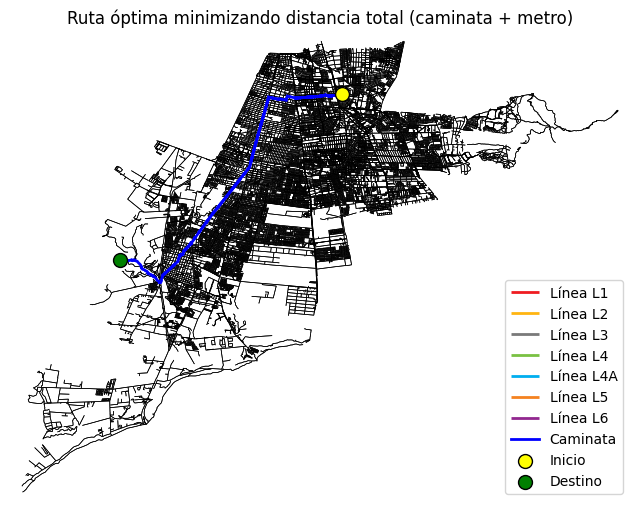

In [84]:
from shapely.geometry import LineString
import matplotlib.pyplot as plt

# 1. Figura con fondo blanco
fig, ax = ox.plot_graph(
    G_walk,
    show=False,
    close=False,
    node_size=0,
    edge_color='black',
    edge_linewidth=0.5,
    bgcolor='white'
)

# 2. Colores oficiales del metro
colores_metro = {
    'L1': '#EF1C22',
    'L2': '#FFB511',
    'L3': '#7A7A7A',
    'L4': '#7AC143',
    'L4A': '#00AEEF',
    'L5': '#F58220',
    'L6': '#92278F',
}

# 3. Dibujar líneas de metro (por color)
for linea_id, color in colores_metro.items():
    linea = lineas_metro[lineas_metro['LINEA'] == linea_id]
    if not linea.empty:
        linea.plot(ax=ax, linewidth=2, color=color, label=f'Línea {linea_id}')

# 4. Separar rutas: caminata / metro
coords_walk = []
coords_metro = []
for u, v in zip(ruta_optima[:-1], ruta_optima[1:]):
    if G_walk.has_edge(u, v) or G_walk.has_edge(v, u):
        # Es caminata
        edge_data = G_walk.get_edge_data(u, v, default=G_walk.get_edge_data(v, u))
        geom = edge_data[0].get('geometry')
        if geom:
            coords_walk.append(geom)
        else:
            coords_walk.append(LineString([
                (G_walk.nodes[u]['x'], G_walk.nodes[u]['y']),
                (G_walk.nodes[v]['x'], G_walk.nodes[v]['y']),
            ]))
    else:
        # Es metro
        try:
            geom = G_walk[u][v][0]['geometry']
        except:
            geom = LineString([
                (G_walk.nodes[u]['x'], G_walk.nodes[u]['y']),
                (G_walk.nodes[v]['x'], G_walk.nodes[v]['y']),
            ])
        coords_metro.append(geom)

# 5. Detectar caminatas que se superponen con líneas de metro
tramos_superpuestos = []
tramos_caminata_puros = []

# Unir todas las geometrías de metro
union_metro = lineas_metro.unary_union

for geom in coords_walk:
    if geom.intersects(union_metro):
        tramos_superpuestos.append(geom)
    else:
        tramos_caminata_puros.append(geom)

# 6. Dibujar caminata pura (azul)
for line in tramos_caminata_puros:
    xs, ys = line.xy
    ax.plot(xs, ys, color='blue', linewidth=2, label='Caminata')

# 7. Dibujar caminata que coincide con metro (rojo)
for line in tramos_superpuestos:
    xs, ys = line.xy
    ax.plot(xs, ys, color='red', linewidth=2, label='Caminata sobre metro')

# 9. Puntos de inicio y destino
ax.scatter(G_walk.nodes[orig_node_total]['x'], G_walk.nodes[orig_node_total]['y'],
           color='yellow', edgecolors='black', s=100, zorder=5, label='Inicio')

ax.scatter(G_walk.nodes[dest_node_total]['x'], G_walk.nodes[dest_node_total]['y'],
           color='green', edgecolors='black', s=100, zorder=5, label='Destino')

# 10. Leyenda sin duplicados
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc='lower right')

# 11. Mostrar mapa
plt.title('Ruta óptima minimizando distancia total (caminata + metro)', fontsize=12)
plt.axis('off')
plt.show()

## b) Nodos críticos y puntos de riesgo

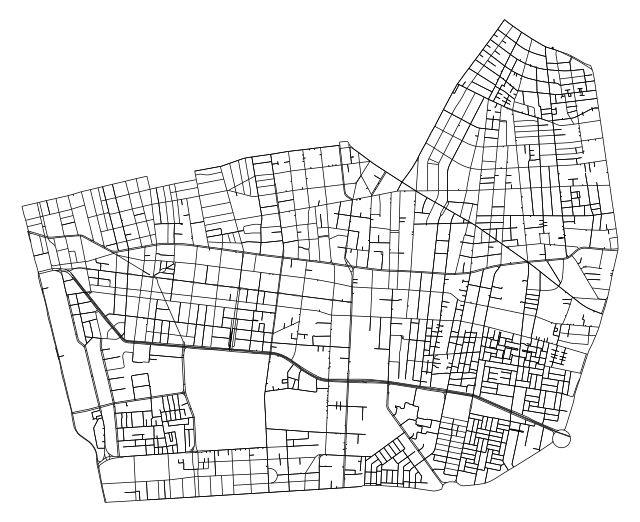

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [116]:
G_nunoa = ox.graph_from_place('Ñuñoa, Santiago, Chile', network_type='drive')
ox.plot_graph(G_nunoa, node_size=0, edge_linewidth=0.5, edge_color='black', bgcolor='white', show=True, close=True)

In [117]:
betweenness = nx.betweenness_centrality(G_nunoa, normalized=True)
closeness = nx.closeness_centrality(G_nunoa)

In [133]:
# Identificar nodos en percentil 90 de ambas métricas

N = len(G_nunoa.nodes())
n = np.ceil(0.1*N)

top_betweenness = sorted(betweenness, key=betweenness.get, reverse=True)[:int(n)]
top_closeness = sorted(closeness, key=closeness.get, reverse=True)[:int(n)]

nodes = list(set(top_betweenness) & set(top_closeness))
print(f'Nodos en percentil 90 de ambas métricas: {len(nodes)}')

Nodos en percentil 90 de ambas métricas: 115


Importar puntos críticos de accidentes

In [118]:
puntos_criticos = gpd.read_file('Data L5/Accidentes/Puntos_criticos_2019.geojson')
puntos_criticos = puntos_criticos.to_crs("EPSG:4326")

Imprimir valores únicos de columna 'Comuna'

In [119]:
print(puntos_criticos['Comuna'].unique())

['SANTIAGO' 'LO BARNECHEA' 'SAN MIGUEL' 'INDEPENDENCIA' 'RECOLETA'
 'SAN RAMON' 'SAN JOAQUIN' 'HUECHURABA' 'LA GRANJA' 'PROVIDENCIA'
 'LA PINTANA' 'PUENTE ALTO' 'Ã‘UÃ‘OA' 'MACUL' 'LA FLORIDA' 'LAS CONDES'
 'PEÃ‘ALOLEN' 'VITACURA' 'LA REINA' 'MAIPU' 'PUDAHUEL' 'CERRILLOS'
 'QUILICURA' 'LO PRADO' 'ESTACION CENTRAL' 'RENCA' 'CERRO NAVIA'
 'SAN BERNARDO' 'QUINTA NORMA' 'LO ESPEJO' 'EL BOSQUE' 'CONCHALI'
 'PEDRO AGUIRRE CERDA' 'LA CISTERNA']


In [120]:
puntos_criticos_nunoa = puntos_criticos[puntos_criticos['Comuna'] == 'Ã‘UÃ‘OA']
puntos_criticos_nunoa.head()

,FID,Ano,Codregion,Region,Comuna,Zona,Calle1,Calle2,Numero,lat,...,Cód_Calza,Calzada,Cód__Tipo,Tipo_Calza,Fallecidos,Graves,Menos_Grav,Leves,Accidentes,geometry
142,143,2019,13,REGION METROPOLITANA,Ã‘UÃ‘OA,URBANA,VICUNA MACKENNA,RODRIGO DE ARAYA,NULL,-33.474937,...,3,BIDIRECCIONAL CON BANDEJON,2,ASFALTO,0,0,0,0,6,POINT (-70.62313 -33.47494)
152,153,2019,13,REGION METROPOLITANA,Ã‘UÃ‘OA,URBANA,SUCRE,JULIO PRADO,NULL,-33.450024,...,1,UNIDIRECCIONAL,2,ASFALTO,0,1,0,4,6,POINT (-70.62017 -33.45002)
165,166,2019,13,REGION METROPOLITANA,Ã‘UÃ‘OA,URBANA,GRECIA,REP DE ISRAEL,NULL,-33.461567,...,3,BIDIRECCIONAL CON BANDEJON,2,ASFALTO,0,2,0,2,5,POINT (-70.61494 -33.46157)
172,173,2019,13,REGION METROPOLITANA,Ã‘UÃ‘OA,URBANA,MARATHON,GUILLERMO MANN,NULL,-33.470577,...,3,BIDIRECCIONAL CON BANDEJON,2,ASFALTO,0,0,0,1,5,POINT (-70.61362 -33.47058)
186,187,2019,13,REGION METROPOLITANA,Ã‘UÃ‘OA,URBANA,CAMPOS DE DEPORTES,CRESCENTE ERRAZURIZ,NULL,-33.458515,...,3,BIDIRECCIONAL CON BANDEJON,2,ASFALTO,0,2,0,5,7,POINT (-70.60978 -33.45851)


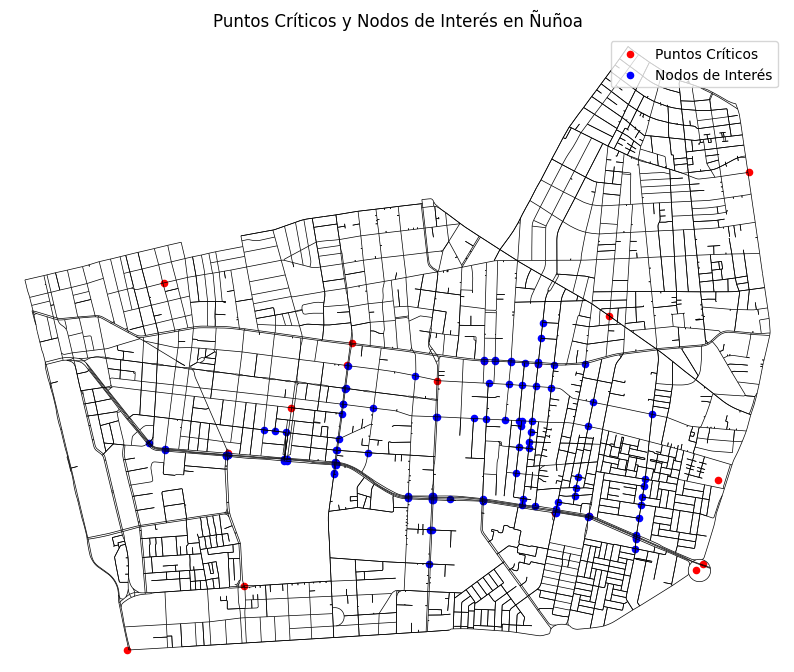

In [134]:
# plotear puntos críticos y nodos de interés
fig, ax = plt.subplots(figsize=(10, 10))
puntos_criticos_nunoa.plot(ax=ax, color='red', markersize=20, label='Puntos Críticos')
for node in nodes:
    x, y = G_nunoa.nodes[node]['x'], G_nunoa.nodes[node]['y']
    ax.scatter(x, y, color='blue', s=20, label='Nodos de Interés' if node == nodes[0] else "")
ox.plot_graph(G_nunoa, ax=ax, node_size=0, edge_linewidth=0.5, edge_color='black', bgcolor='white', show=False, close=False)
ax.set_title('Puntos Críticos y Nodos de Interés en Ñuñoa')
ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')
ax.legend()
plt.show()

## c) Ruta mínima entre zonas clave

In [122]:
distritos_censales = gpd.read_file('Data L5/Distritos Censales/Distritos Censales RM.shp')
distritos_censales = distritos_censales.to_crs("EPSG:4326")

Filtrar distritos urbanos de santiago

In [123]:
distritos_censales = gpd.overlay(distritos_censales, santiago_urbano, how='intersection')

In [124]:
distritos_censales.columns

Index(['NOM_REG', 'COD_PROV', 'NOM_PROV', 'COD_COM', 'NOM_COM', 'NOM_DIS',
       'CODIGO', 'E', 'D', 'C3', 'C2', 'ABC1', 'ADIMARK_T', 'Area', 'Densidad',
       '1_UF_M2', 'NOMBRE', 'TIPO_AREA', 'SHAPE_Leng', 'SHAPE_Area',
       'geometry'],
      dtype='object')

In [125]:
# recuperar distrito con mayor 'Densidad'
distrito_mayor_densidad = distritos_censales.loc[distritos_censales['Densidad'].idxmax()]

# recuperar distrito con mayor valor de suelo
distrito_mayor_valor = distritos_censales.loc[distritos_censales['1_UF_M2'].idxmax()]

In [126]:
# Leemos la información de seguridad
seguridad_1 = gpd.read_file('Data L5/Seguridad/seguridad_santiago.csv')

# Incorporamos la geometría
geometria = [Point(xy) for xy in zip(seguridad_1['lon'], seguridad_1['lat'])]

seguridad = gpd.GeoDataFrame(seguridad_1, geometry=geometria, crs="EPSG:4326")
seguridad = seguridad.drop(columns=['lon', 'lat'])

print(seguridad.head())

# Computamos la percepción de seguridad promedio por distrito
seguridad_joined = gpd.sjoin(seguridad, distritos_censales, how="inner", predicate="within")
seguridad_joined['seguridad'] = pd.to_numeric(seguridad_joined['seguridad'], errors='coerce')
seguridad_avg = seguridad_joined.groupby('NOM_DIS')['seguridad'].mean().reset_index()

# Unimos la información de seguridad con los distritos
distritos_censales = distritos_censales.merge(seguridad_avg, on ='NOM_DIS', how='left')

             seguridad                     geometry
0  -0.1204561762476047  POINT (-70.51263 -33.32394)
1  -0.1030424111992832  POINT (-70.51273 -33.32394)
2   0.3911718268913759  POINT (-70.51299 -33.32394)
3  0.30085614658947296  POINT (-70.51344 -33.32394)
4  -0.9463546052120152   POINT (-70.5138 -33.32394)


In [127]:
distritos_censales.head()

,NOM_REG,COD_PROV,NOM_PROV,COD_COM,NOM_COM,NOM_DIS,CODIGO,E,D,C3,...,ADIMARK_T,Area,Densidad,1_UF_M2,NOMBRE,TIPO_AREA,SHAPE_Leng,SHAPE_Area,geometry,seguridad
0,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Huelén,1310101.0,28.0,397.0,1232.0,...,3412.0,704315.75,48.44,31.09,Santiago,Ciudad,427491.444262,5.821041e+08,"POLYGON ((-70.64812 -33.4333, -70.64645 -33.43...",0.072123
1,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Moneda,1310102.0,51.0,560.0,999.0,...,2741.0,1166659.89,23.49,21.10,Santiago,Ciudad,427491.444262,5.821041e+08,"POLYGON ((-70.65698 -33.43182, -70.65337 -33.4...",-0.150945
2,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Amunátegui,1310103.0,38.0,389.0,956.0,...,2387.0,509080.85,46.89,12.00,Santiago,Ciudad,427491.444262,5.821041e+08,"POLYGON ((-70.66031 -33.43095, -70.65861 -33.4...",-0.194270
3,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Brasil,1310104.0,52.0,657.0,1728.0,...,5062.0,761738.52,66.45,10.25,Santiago,Ciudad,427491.444262,5.821041e+08,"POLYGON ((-70.6602 -33.43747, -70.66004 -33.43...",-0.038582
4,Región Metropolitana De Santiago,131,Santiago,13101,Santiago,Chacabuco,1310105.0,45.0,643.0,1092.0,...,2899.0,765782.74,37.86,11.87,Santiago,Ciudad,427491.444262,5.821041e+08,"POLYGON ((-70.67786 -33.44386, -70.66817 -33.4...",0.002517


In [128]:
# recuperar distrito con menor percepción de seguridad
distrito_menor_seguridad = distritos_censales.loc[distritos_censales['seguridad'].idxmin()]

In [129]:
robos_violencia = gpd.read_file('Data L5/Delitos/imfd-delitos-24-robbery-with-violence-or-intimidation/IMFD-Delitos-24-robbery with violence or intimidation.shp')
robos_violencia = robos_violencia.to_crs("EPSG:4326")

In [130]:
distritos_censales['delitos'] = 0.0

months = ['enr', 'fbr', 'mrz', 'abr', 'may', 'jun', 'jul', 'ags', 'spt', 'oct', 'nvm', 'dcm']
month_cols = [col for col in robos_violencia.columns if any(col.startswith(m) for m in months)]

robos_violencia['robos_totales'] = robos_violencia[month_cols].sum(axis=1)
# intersectar
distritos_censales = gpd.overlay(distritos_censales, robos_violencia, how='intersection')

#recuperar distrito con mayor cantidad de robos
distrito_mayor_robos = distritos_censales.loc[distritos_censales['robos_totales'].idxmax()]

In [131]:
# recuperar centroides de cuatro distritos recuperados
centroides = {
    'mayor_densidad': distrito_mayor_densidad.geometry.centroid,
    'mayor_valor_suelo': distrito_mayor_valor.geometry.centroid,
    'menor_seguridad': distrito_menor_seguridad.geometry.centroid,
    'mayor_robos': distrito_mayor_robos.geometry.centroid
}

In [156]:
G_santiago = ox.graph_from_place('Santiago, Chile', network_type='drive')
nodos = {}
for clave, punto in centroides.items():
    nodo = ox.distance.nearest_nodes(G_santiago, punto.x, punto.y)
    nodos[clave] = nodo

In [147]:
grafo_reducido = nx.Graph()
rutas_reales = {}
# Función segura para calcular distancia total de una ruta
def calcular_distancia_total(grafo, ruta):
    distancia = 0
    for u, v in zip(ruta[:-1], ruta[1:]):
        try:
            edge_data = grafo.get_edge_data(u, v)
            if isinstance(edge_data, dict):
                edge = list(edge_data.values())[0]  # primer arco si hay múltiples
            else:
                edge = edge_data
            distancia += edge['length']
        except Exception as e:
            print(f"Error entre {u} y {v}: {e}")
    return distancia


In [157]:
mst = nx.minimum_spanning_tree(grafo_reducido, weight='weight')

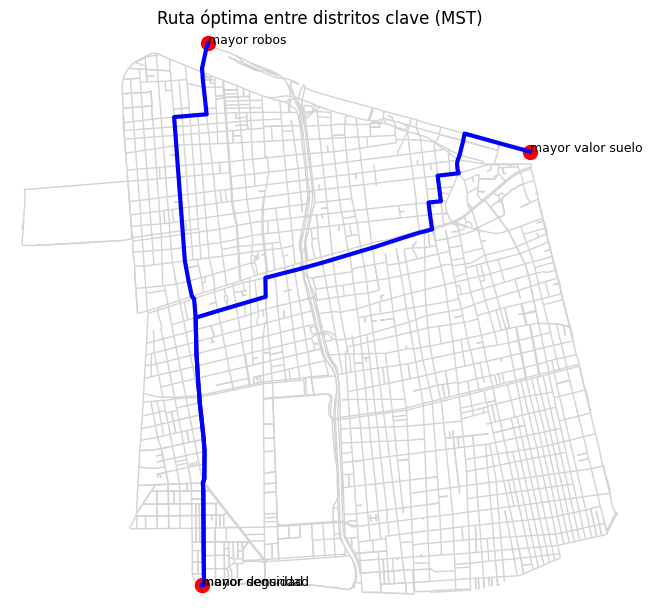

In [158]:
fig, ax = ox.plot_graph(
    G_santiago,
    show=False,
    close=False,
    node_size=0,
    edge_color='lightgray',
    bgcolor='white'
)

# Dibujar rutas del MST en azul
for u, v in mst.edges():
    ruta = rutas_reales.get((u, v)) or rutas_reales.get((v, u))
    xs = [G_santiago.nodes[n]['x'] for n in ruta]
    ys = [G_santiago.nodes[n]['y'] for n in ruta]
    ax.plot(xs, ys, color='blue', linewidth=3)

# Marcar los 4 nodos clave
for nombre, nodo in nodos.items():
    x = G_santiago.nodes[nodo]['x']
    y = G_santiago.nodes[nodo]['y']
    ax.scatter(x, y, s=100, color='red')
    ax.text(x, y, nombre.replace("_", " "), fontsize=9, color='black')

plt.title("Ruta óptima entre distritos clave (MST)")
plt.axis('off')
plt.show()